In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Dmart+Dataset_final-last.xlsx")

df.shape
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Customer ID              25000 non-null  object        
 1   Product ID               25000 non-null  object        
 2   Order ID                 25000 non-null  int64         
 3   Customer Age             25000 non-null  int64         
 4   Gender                   25000 non-null  object        
 5   Product Name             25000 non-null  object        
 6   MRP                      25000 non-null  float64       
 7   Discount Price           25000 non-null  float64       
 8   Category                 25000 non-null  object        
 9   State                    25000 non-null  object        
 10  City                     25000 non-null  object        
 11  Subscription             25000 non-null  object        
 12  Bill Number              25000 n

In [4]:
df.isna().sum()


,0
Customer ID,0
Product ID,0
Order ID,0
Customer Age,0
Gender,0
Product Name,0
MRP,0
Discount Price,0
Category,0
State,0


In [5]:
df["Order Status"].value_counts(normalize=True) * 100


,proportion
Order Status,
Delivered,52.036
Shipped,35.428
Cancelled,7.136
Returned,5.400


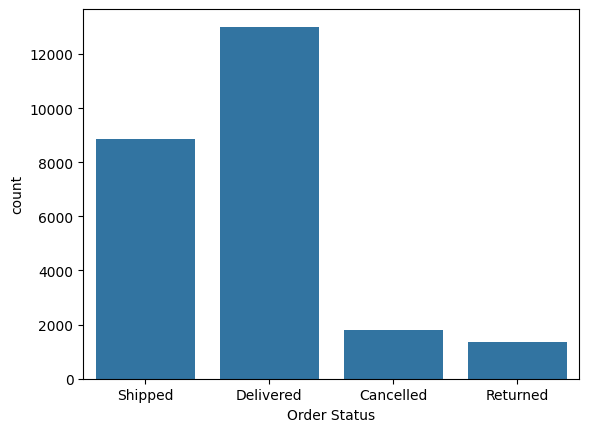

In [6]:
sns.countplot(data=df, x="Order Status")
plt.show()


In [7]:
pd.crosstab(df["Order Status"], df["Payment Status"])


Payment Status,Paid,Pending,Refunded,Voided
Order Status,,,,
Cancelled,0,0,0,1784
Delivered,10381,2628,0,0
Returned,0,0,1350,0
Shipped,7083,1774,0,0


In [8]:
df["Total_revenue_per_order"].describe()


,Total_revenue_per_order
count,25000.000000
mean,678.164373
std,488.629285
min,0.000000
25%,250.157500
50%,656.040000
75%,1045.692500
max,2026.220000


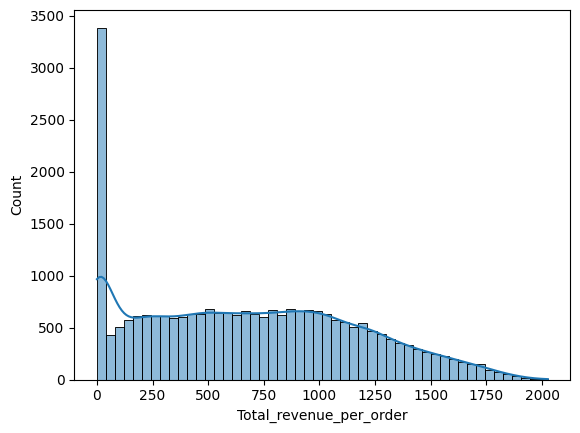

In [9]:
sns.histplot(df["Total_revenue_per_order"], bins=50, kde=True)
plt.show()


In [10]:
df.groupby("Category").agg(
    Total_Revenue=("Total_revenue_per_order", "sum"),
    Order_Count=("Order ID", "count"),
    Avg_Revenue=("Total_revenue_per_order", "mean")
).sort_values("Total_Revenue", ascending=False)


,Total_Revenue,Order_Count,Avg_Revenue
Category,,,
Local,8482035.48,12402,683.924809
Branded,5124795.11,7564,677.524473
Imported,3347278.74,5034,664.934195


In [11]:
df.groupby("Subscription").agg(
    Total_Revenue=("Total_revenue_per_order", "sum"),
    Order_Count=("Order ID", "count"),
    Avg_Revenue=("Total_revenue_per_order", "mean")
)


,Total_Revenue,Order_Count,Avg_Revenue
Subscription,,,
Freepass,9720904.67,13963,696.190265
Premium,5173184.71,7861,658.082268
Premium Plus,2060019.95,3176,648.620891


In [12]:
df.groupby("State").agg(
    Total_Revenue=("Total_revenue_per_order", "sum"),
    Order_Count=("Order ID", "count"),
    Avg_Revenue=("Total_revenue_per_order", "mean")
).sort_values("Total_Revenue", ascending=False)


,Total_Revenue,Order_Count,Avg_Revenue
State,,,
Maharashtra,4298236.76,6343,677.634678
Andhra Pradesh,4249018.44,6271,677.566328
Gujarat,4225412.10,6244,676.715583
Telangana,4181442.03,6142,680.794860


In [13]:
df["Discount Percentage "].describe()


,Discount Percentage
count,25000.000000
mean,0.274444
std,0.130436
min,0.049855
25%,0.160001
50%,0.270004
75%,0.389998
max,0.500221


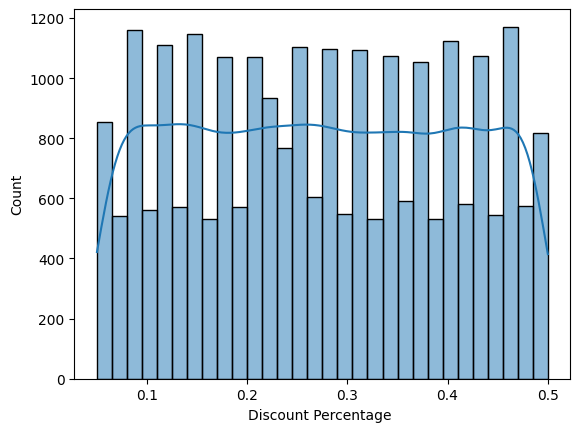

In [14]:
sns.histplot(df["Discount Percentage "], bins=30, kde=True)
plt.show()


In [15]:
df.groupby("Order Status")["Discount Percentage "].mean()


,Discount Percentage
Order Status,
Cancelled,0.276088
Delivered,0.274844
Returned,0.273800
Shipped,0.273626


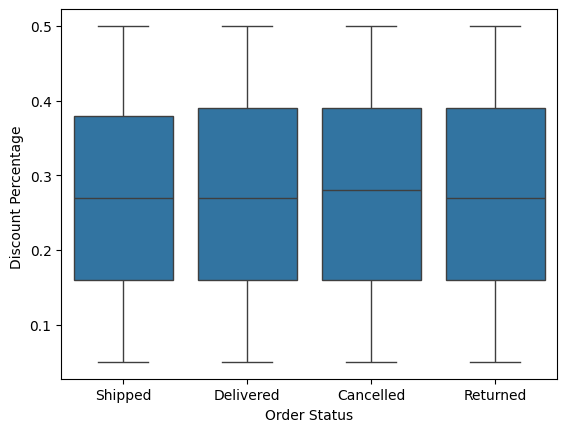

In [16]:
sns.boxplot(data=df, x="Order Status", y="Discount Percentage ")
plt.show()


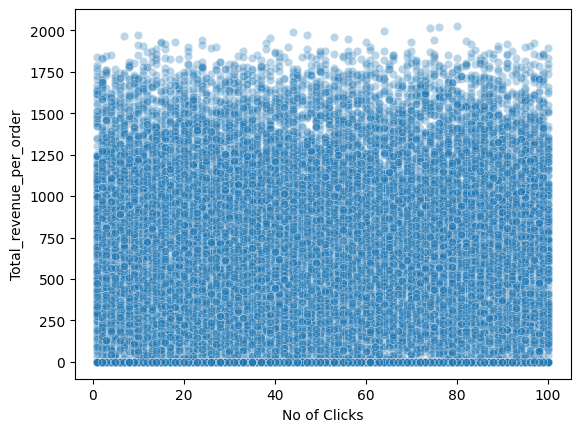

In [17]:
sns.scatterplot(
    data=df,
    x="No of Clicks",
    y="Total_revenue_per_order",
    alpha=0.3
)
plt.show()


In [18]:
df.groupby("Order Status")["Total_revenue_per_order"].sum()

,Total_revenue_per_order
Order Status,
Cancelled,0.00
Delivered,10048788.46
Returned,0.00
Shipped,6905320.87


In [19]:
payment_discount_revenue = (
    df.assign(
        Discount_Bucket=pd.cut(
            df["Discount Percentage "],
            bins=[0, 0.2, 0.3, 0.5],
            labels=["Low", "Medium", "High"]
        )
    )
    .groupby(["Payment Method", "Discount_Bucket"])
    .agg(
        Total_Revenue=("Total_revenue_per_order", "sum"),
        Order_Count=("Order ID", "count"),
        Avg_Revenue=("Total_revenue_per_order", "mean")
    )
    .sort_values("Total_Revenue", ascending=False)
)
payment_discount_revenue

/tmp/ipython-input-1585177151.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Payment Method", "Discount_Bucket"])


Total_Revenue  Order_Count  Avg_Revenue
Payment Method Discount_Bucket                                         
Debit          Low                 2695431.26         3109   866.976925
               High                2504490.28         4108   609.661704
Credit         Low                 2122990.38         2392   887.537784
               High                1864266.75         3078   605.674708
Debit          Medium              1562973.14         2058   759.462167
Credit         Medium              1124385.88         1525   737.302216
UPI            Low                 1037702.20         1177   881.650127
               High                 945985.89         1510   626.480722
Netbanking     Low                  632709.10          733   863.177490
UPI            Medium               601994.42          812   741.372438
Netbanking     High                 596473.78          970   614.921423
               Medium               386908.71          516   749.823081
COD            Low                  359179.87          420   855.190167
               High                 288833.36          476   606.792773
               Medium               194592.00          265   734.309434
Cancelled      Medium                    0.00          384     0.000000
               High                      0.00          796     0.000000
               Low                       0.00          599     0.000000

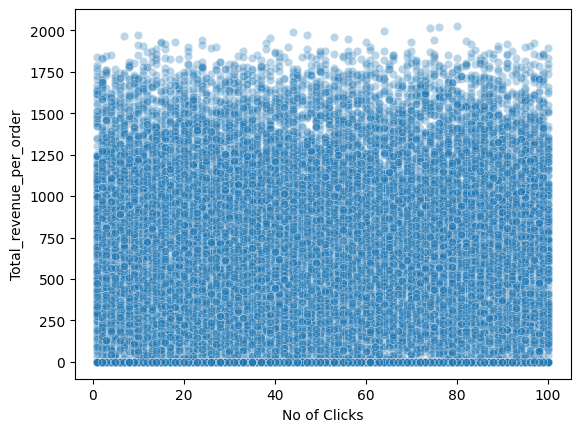

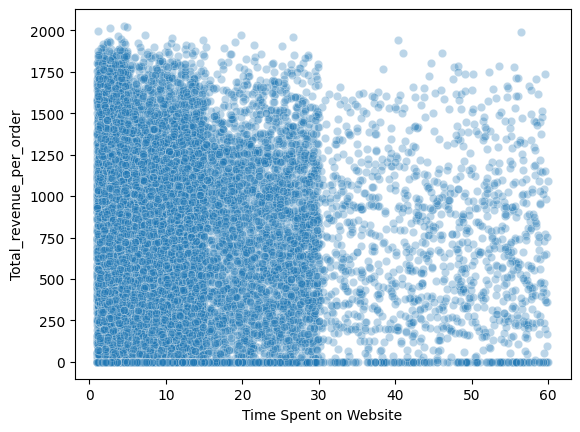

In [20]:
sns.scatterplot(
    data=df,
    x="No of Clicks",
    y="Total_revenue_per_order",
    alpha=0.3
)
plt.show()
sns.scatterplot(
    data=df,
    x="Time Spent on Website",
    y="Total_revenue_per_order",
    alpha=0.3
)
plt.show()


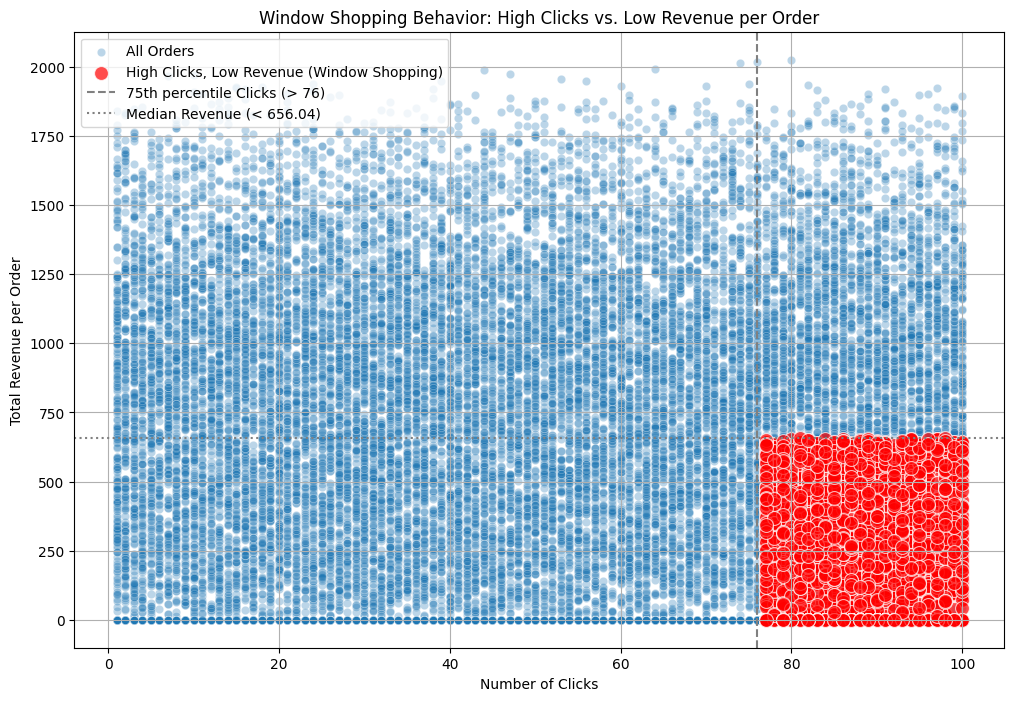

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the window shopping criteria
clicks_threshold = df['No of Clicks'].quantile(0.75)
revenue_threshold = df['Total_revenue_per_order'].median()

# Filter for window shopping orders
window_shopping_df = df[
    (df['No of Clicks'] > clicks_threshold) &
    (df['Total_revenue_per_order'] < revenue_threshold)]
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='No of Clicks',
    y='Total_revenue_per_order',
    alpha=0.3, # Make base data translucent
    label='All Orders')

sns.scatterplot( data=window_shopping_df,
    x='No of Clicks',
    y='Total_revenue_per_order',
    color='red',
    s=100, # Make points larger
    alpha=0.7,
    label='High Clicks, Low Revenue (Window Shopping)'
)

plt.axvline(x=clicks_threshold, color='grey', linestyle='--', label=f'75th percentile Clicks (> {clicks_threshold:.0f})')
plt.axhline(y=revenue_threshold, color='grey', linestyle=':', label=f'Median Revenue (< {revenue_threshold:.2f})')

plt.title('Window Shopping Behavior: High Clicks vs. Low Revenue per Order')
plt.xlabel('Number of Clicks')
plt.ylabel('Total Revenue per Order')
plt.legend()
plt.grid(True)
plt.show()


In [22]:
df["Customer_Order_Count"] = df.groupby("Customer ID")["Order ID"].transform("count")

df.groupby("Customer_Order_Count").agg(
    Total_Revenue=("Total_revenue_per_order", "sum"),
    Avg_Revenue=("Total_revenue_per_order", "mean"),
    Customer_Count=("Customer ID", "nunique")
)


,Total_Revenue,Avg_Revenue,Customer_Count
Customer_Order_Count,,,
1,16698765.61,678.039857,24628
2,255343.72,686.407849,186


In [23]:
df.groupby("Age category")["Total_revenue_per_order"].sum().sort_values(ascending=False)
df.groupby("Age category").agg(
    Total_Revenue=("Total_revenue_per_order", "sum"),
    Order_Count=("Order ID", "count"),
    Avg_Revenue=("Total_revenue_per_order", "mean")
)


,Total_Revenue,Order_Count,Avg_Revenue
Age category,,,
Adult,6512946.66,9551,681.912539
Middle Aged,6296916.00,9314,676.070002
Senior,1590806.83,2348,677.515686
Young,2553439.84,3787,674.264547


model eda


In [24]:
# Basic distribution
print(df["Total_revenue_per_order"].describe())

# Skewness
print(df["Total_revenue_per_order"].skew())

# Log transform (optional for modeling)
df["log_revenue"] = np.log1p(df["Total_revenue_per_order"])

count    25000.000000
mean       678.164373
std        488.629285
min          0.000000
25%        250.157500
50%        656.040000
75%       1045.692500
max       2026.220000
Name: Total_revenue_per_order, dtype: float64
0.2801970322726991


In [25]:
Q1 = df["Total_revenue_per_order"].quantile(0.25)
Q3 = df["Total_revenue_per_order"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["Total_revenue_per_order"] < Q1 - 1.5 * IQR) |
    (df["Total_revenue_per_order"] > Q3 + 1.5 * IQR)
]

outliers.shape


(0, 38)

In [26]:
# Revenue variance by key features
# First, ensure 'Discount_Bucket' exists in df
df["Discount_Bucket"] = pd.cut(
    df["Discount Percentage "],
    bins=[0, 0.2, 0.3, 0.5],
    labels=["Low", "Medium", "High"]
)

print(df.groupby("Category")["Total_revenue_per_order"].var())
print(df.groupby("Subscription")["Total_revenue_per_order"].var())
print(df.groupby("Discount_Bucket")["Total_revenue_per_order"].var())

Category
Branded     237805.890557
Imported    234318.462237
Local       241075.652093
Name: Total_revenue_per_order, dtype: float64
Subscription
Freepass        243187.860391
Premium         233072.371612
Premium Plus    230207.426070
Name: Total_revenue_per_order, dtype: float64
Discount_Bucket
Low       317876.790810
Medium    233476.129103
High      154800.402531
Name: Total_revenue_per_order, dtype: float64


/tmp/ipython-input-3966485167.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("Discount_Bucket")["Total_revenue_per_order"].var())


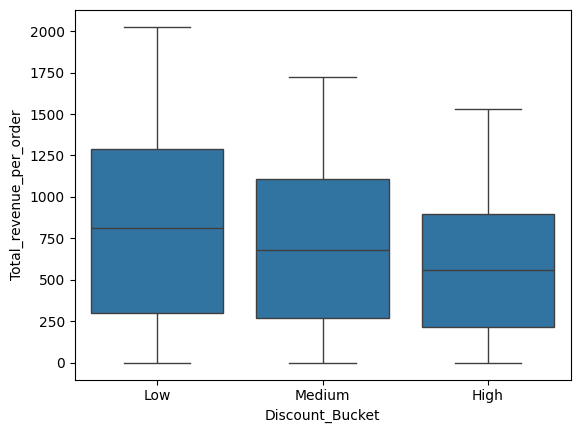

In [27]:
sns.boxplot(
    data=df,
    x="Discount_Bucket",
    y="Total_revenue_per_order"
)
plt.show()


In [28]:
discount_category = (
    df.groupby(["Category", "Discount_Bucket"])
      .agg(
          Avg_Revenue=("Total_revenue_per_order", "mean"),
          Order_Count=("Order ID", "count")
      )
      .reset_index()
)

discount_category


/tmp/ipython-input-1544187154.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Category", "Discount_Bucket"])


,Category,Discount_Bucket,Avg_Revenue,Order_Count
0,Branded,Low,814.267478,2573
1,Branded,Medium,706.814772,1687
2,Branded,High,556.680509,3284
3,Imported,Low,781.321907,1652
4,Imported,Medium,690.825597,1122
5,Imported,High,567.446460,2246
6,Local,Low,823.343353,4205
7,Local,Medium,691.876158,2751
8,Local,High,572.748987,5408


In [29]:
discount_subscription = (
    df.groupby(["Subscription", "Discount_Bucket"])
      .agg(
          Avg_Revenue=("Total_revenue_per_order", "mean"),
          Order_Count=("Order ID", "count")
      )
      .reset_index()
)

discount_subscription


/tmp/ipython-input-360765725.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Subscription", "Discount_Bucket"])


,Subscription,Discount_Bucket,Avg_Revenue,Order_Count
0,Freepass,Low,828.130816,4693
1,Freepass,Medium,721.110904,3120
2,Freepass,High,582.842768,6119
3,Premium,Low,797.840770,2664
4,Premium,Medium,668.031977,1710
5,Premium,High,547.880217,3462
6,Premium Plus,Low,779.261025,1073
7,Premium Plus,Medium,655.689658,730
8,Premium Plus,High,543.016839,1357


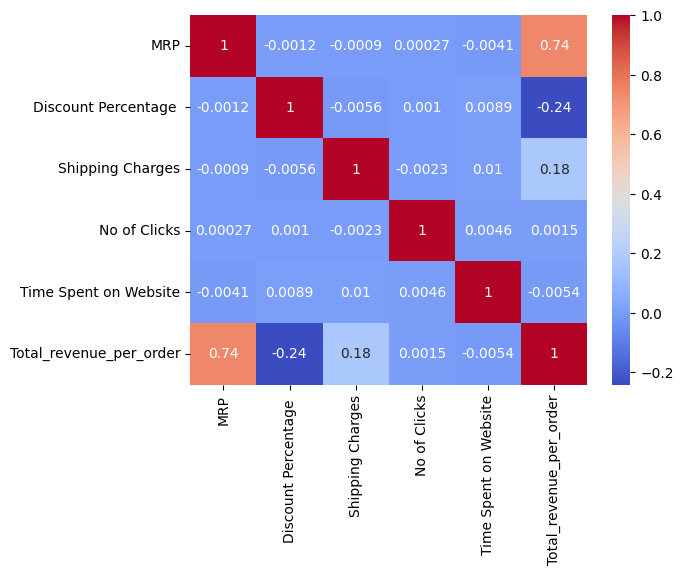

In [30]:
numeric_cols = [
    "MRP",
    "Discount Percentage ",
    "Shipping Charges",
    "No of Clicks",
    "Time Spent on Website",
    "Total_revenue_per_order"
]

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()


In [31]:
leakage_cols = [
    "Order Status",
    "Payment Status",
    "Cancellation Date",
    "Payment Mismatch Flag"
]

df[leakage_cols].head()


,Order Status,Payment Status,Cancellation Date,Payment Mismatch Flag
0,Shipped,Paid,NaT,OK
1,Shipped,Paid,NaT,OK
2,Delivered,Paid,NaT,OK
3,Delivered,Pending,NaT,Mismatch
4,Shipped,Paid,NaT,OK


In [32]:
# Actual revenue by region
actual_region_revenue = (
    df.groupby("State")["Total_revenue_per_order"]
      .sum()
)

# Sanity: total should match
actual_region_revenue.sum(), df["Total_revenue_per_order"].sum()


(np.float64(16954109.33), np.float64(16954109.330000002))

In [33]:
model_df = df[
    [
        "Total_revenue_per_order",
        "log_revenue",
        "Category",
        "Subscription",
        "Discount Percentage ",
        "Shipping Charges",
        "No of Clicks",
        "Time Spent on Website",
        "State"
    ]
].copy()

model_df.head()


,Total_revenue_per_order,log_revenue,Category,Subscription,Discount Percentage,Shipping Charges,No of Clicks,Time Spent on Website,State
0,909.02,6.813467,Imported,Premium,0.069999,0,29,4.18,Andhra Pradesh
1,450.41,6.112376,Branded,Freepass,0.459998,0,95,7.51,Telangana
2,1007.58,6.916299,Branded,Freepass,0.080004,0,51,1.79,Gujarat
3,489.04,6.194487,Imported,Freepass,0.480004,100,12,1.15,Maharashtra
4,1011.80,6.920474,Local,Freepass,0.269999,100,26,1.31,Gujarat


feature engneering

In [34]:
fe_df = df.copy()


In [35]:
# Target
y = fe_df["Total_revenue_per_order"]

# Optional log target (recommended for linear models)
y_log = fe_df["log_revenue"]


In [36]:
fe_df["Discount_Amount"] = fe_df["MRP"] * fe_df["Discount Percentage "]


In [37]:
fe_df["Shipping_Ratio"] = (
    fe_df["Shipping Charges"] / fe_df["Total_revenue_per_order"]
).replace([np.inf, -np.inf], 0).fillna(0)


In [38]:
fe_df["Clicks_per_Minute"] = (
    fe_df["No of Clicks"] / fe_df["Time Spent on Website"]
).replace([np.inf, -np.inf], 0).fillna(0)


In [39]:
feature_cols = [
    # Numeric
    "MRP",
    "Discount Percentage ",
    "Discount_Amount",
    "Shipping Charges",
    "Shipping_Ratio",
    "No of Clicks",
    "Time Spent on Website",
    "Clicks_per_Minute",

    # Categorical
    "Category",
    "Subscription",
    "State"
]

X = fe_df[feature_cols]


In [40]:
X_encoded = pd.get_dummies(
    X,
    columns=["Category", "Subscription", "State"],
    drop_first=True
)


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = [
    "MRP",
    "Discount Percentage ",
    "Discount_Amount",
    "Shipping Charges",
    "Shipping_Ratio",
    "No of Clicks",
    "Time Spent on Website",
    "Clicks_per_Minute"
]

X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])


In [42]:
X_encoded.shape
X_encoded.head()


,MRP,Discount Percentage,Discount_Amount,Shipping Charges,Shipping_Ratio,No of Clicks,Time Spent on Website,Clicks_per_Minute,Category_Imported,Category_Local,Subscription_Premium,Subscription_Premium Plus,State_Gujarat,State_Maharashtra,State_Telangana
0,-0.063577,-1.567428,-0.960841,-0.713984,-0.508984,-0.742120,-0.544506,-0.371847,True,False,True,False,False,False,False
1,-0.314597,1.422593,0.483639,-0.713984,-0.508984,1.544200,-0.240834,0.023649,False,False,False,False,False,False,True
2,0.142633,-1.490727,-0.872870,-0.713984,-0.508984,0.019987,-0.762457,1.120529,False,False,False,False,True,False,False
3,-0.465070,1.575973,0.371108,1.226243,1.130909,-1.331021,-0.820821,-0.129717,True,False,False,False,False,True,False
4,0.412023,-0.034080,0.270857,1.226243,0.283636,-0.846044,-0.806230,0.522003,False,True,False,False,True,False,False


modeling

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


In [45]:
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)

lr_r2, lr_rmse, lr_mae

(0.6529549197188671, np.float64(287.9538855724652), 166.55288205311177)

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [47]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

rf_r2 = r2_score(y_test, y_pred_rf)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)

rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_r2, rf_rmse, rf_mae


(0.7271860082164079, np.float64(255.30734960249399), 127.75245935186418)

In [48]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [lr_r2, rf_r2],
    "RMSE": [lr_rmse, rf_rmse],
    "MAE": [lr_mae, rf_mae]
})

model_comparison


,Model,R2,RMSE,MAE
0,Linear Regression,0.652955,287.953886,166.552882
1,Random Forest,0.727186,255.307350,127.752459


In [49]:
# Ensure Order Date is datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Aggregate monthly revenue
monthly_revenue = (
    df
    .set_index("Order Date")
    .resample("ME")["Total_revenue_per_order"]
    .sum()
    .to_frame(name="Revenue")
)

monthly_revenue.head()


,Revenue
Order Date,
2021-01-31,450818.55
2021-02-28,408273.45
2021-03-31,462025.11
2021-04-30,466983.55
2021-05-31,461050.08


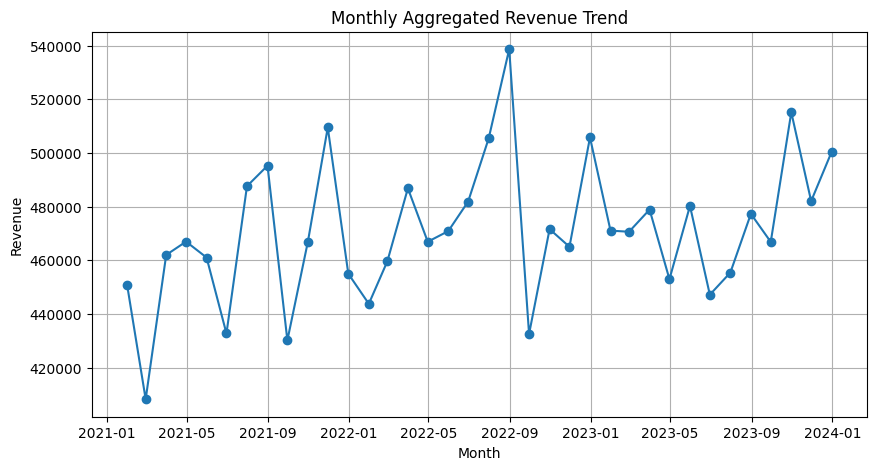

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index, monthly_revenue["Revenue"], marker="o")
plt.title("Monthly Aggregated Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()


In [51]:
# Use last 3 months as test data
train = monthly_revenue.iloc[:-3]
test = monthly_revenue.iloc[-3:]


In [52]:
seasonal_naive_forecast = train["Revenue"].iloc[-12:-9].values


In [53]:
seasonal_naive_forecast = train["Revenue"].iloc[-12:-9].values

print("Seasonal Naive Forecast (next 3 months):")
print(seasonal_naive_forecast)

print("\nActual Revenue (next 3 months):")
print(test["Revenue"].values)

Seasonal Naive Forecast (next 3 months):
[471629.99 465059.1  505785.94]

Actual Revenue (next 3 months):
[515156.5  482071.66 500456.62]


In [54]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train["Revenue"],
    trend="add",
    seasonal=None,   # No strong seasonality detected
    initialization_method="estimated"
)

hw_fit = hw_model.fit()
hw_forecast = hw_fit.forecast(steps=3)


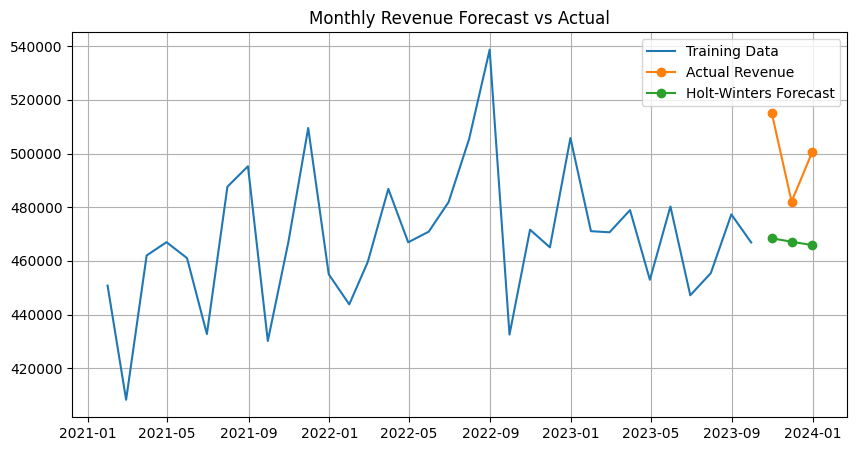

In [55]:
forecast_index = test.index

plt.figure(figsize=(10,5))
plt.plot(train.index, train["Revenue"], label="Training Data")
plt.plot(test.index, test["Revenue"], label="Actual Revenue", marker="o")
plt.plot(forecast_index, hw_forecast, label="Holt-Winters Forecast", marker="o")
plt.legend()
plt.title("Monthly Revenue Forecast vs Actual")
plt.grid(True)
plt.show()


In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["Revenue"], hw_forecast)
rmse = np.sqrt(mean_squared_error(test["Revenue"], hw_forecast))

mae, rmse


(32072.930881687033, np.float64(34648.81831282828))

In [57]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train["Revenue"],
    trend="add",
    seasonal=None,
    initialization_method="estimated"
)

hw_fit = hw_model.fit()
hw_forecast = hw_fit.forecast(steps=3)


In [58]:
comparison_df = pd.DataFrame({
    "Actual_Revenue": test["Revenue"],
    "Seasonal_Naive_Forecast": seasonal_naive_forecast,
    "Holt_Winters_Forecast": hw_forecast
})

comparison_df


,Actual_Revenue,Seasonal_Naive_Forecast,Holt_Winters_Forecast
2023-10-31,515156.50,471629.99,468419.229353
2023-11-30,482071.66,465059.10,467155.329118
2023-12-31,500456.62,505785.94,465891.428884


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

results = pd.DataFrame({
    "Model": ["Seasonal Naive", "Holt-Winters"],
    "MAE": [
        mean_absolute_error(test["Revenue"], seasonal_naive_forecast),
        mean_absolute_error(test["Revenue"], hw_forecast)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(test["Revenue"], seasonal_naive_forecast)),
        np.sqrt(mean_squared_error(test["Revenue"], hw_forecast))
    ]
})

results


,Model,MAE,RMSE
0,Seasonal Naive,21956.130000,27156.251105
1,Holt-Winters,32072.930882,34648.818313


/tmp/ipython-input-3437775908.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('Order Date').resample('M')['Total_revenue_per_order'].sum().reset_index()
/tmp/ipython-input-3437775908.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=monthly['Date'].max(), periods=7, freq='M')[1:]
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Forecast Accuracy: 96.03%


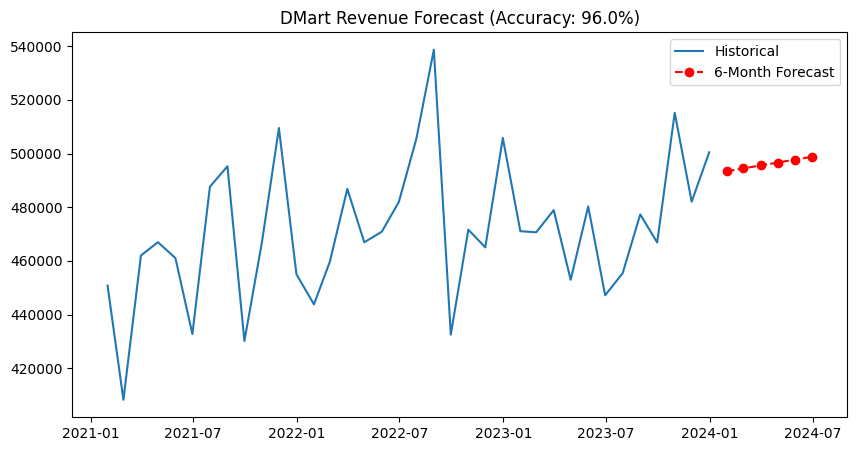

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# 1. DATA PREP: Aggregating to Month Level
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly = df.set_index('Order Date').resample('M')['Total_revenue_per_order'].sum().reset_index()
monthly.columns = ['Date', 'Revenue']

# 2. FEATURE ENGINEERING: Time Index
monthly['t'] = np.arange(len(monthly))

# 3. TEMPORAL SPLIT: No shuffling!
train_size = int(len(monthly) * 0.8)
train, test = monthly.iloc[:train_size], monthly.iloc[train_size:]

# 4. MODELING: Linear Trend
model = LinearRegression()
model.fit(train[['t']], train['Revenue'])

# 5. EVALUATION: Using MAPE for Business Clarity
preds = model.predict(test[['t']])
accuracy = 100 - (mean_absolute_percentage_error(test['Revenue'], preds) * 100)
print(f"Forecast Accuracy: {accuracy:.2f}%")

# 6. PREDICTION: 6-Month Outlook
future_t = np.arange(len(monthly), len(monthly) + 6).reshape(-1, 1)
future_dates = pd.date_range(start=monthly['Date'].max(), periods=7, freq='M')[1:]
forecast = model.predict(future_t)

# 7. VISUALIZATION
plt.figure(figsize=(10, 5))
plt.plot(monthly['Date'], monthly['Revenue'], label='Historical')
plt.plot(future_dates, forecast, 'r--', label='6-Month Forecast', marker='o')
plt.title(f"DMart Revenue Forecast (Accuracy: {accuracy:.1f}%)")
plt.legend()
plt.show()

JUST TESTING PART

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [62]:
df["Order Date"] = pd.to_datetime(df["Order Date"])


In [63]:
monthly_revenue = (
    df
    .set_index("Order Date")
    .resample("M")["Total_revenue_per_order"]
    .sum()
    .reset_index()
)

monthly_revenue.head()


/tmp/ipython-input-1298438360.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Total_revenue_per_order"]


,Order Date,Total_revenue_per_order
0,2021-01-31,450818.55
1,2021-02-28,408273.45
2,2021-03-31,462025.11
3,2021-04-30,466983.55
4,2021-05-31,461050.08


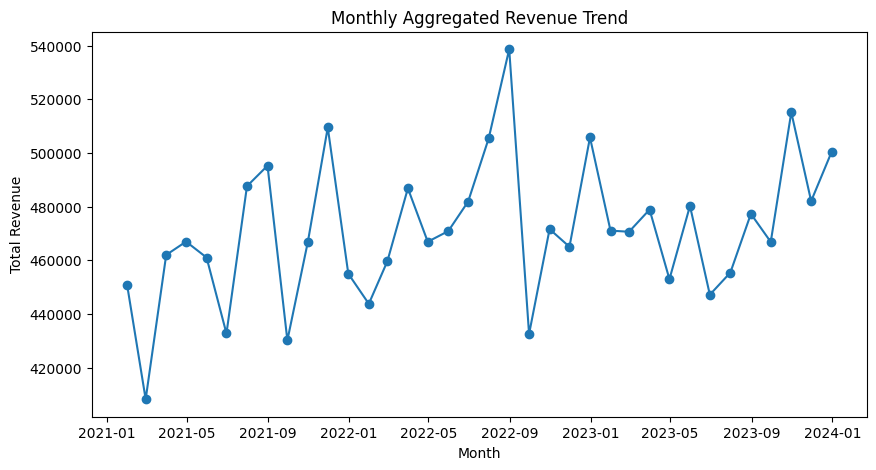

In [64]:
plt.figure(figsize=(10,5))
plt.plot(
    monthly_revenue["Order Date"],
    monthly_revenue["Total_revenue_per_order"],
    marker="o"
)
plt.title("Monthly Aggregated Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()


In [65]:
monthly_revenue["t"] = np.arange(len(monthly_revenue))

X = monthly_revenue[["t"]]
y = monthly_revenue["Total_revenue_per_order"]


In [66]:
trend_model = LinearRegression()
trend_model.fit(X, y)


LinearRegression()

In [67]:
future_periods = 6

future_t = np.arange(
    len(monthly_revenue),
    len(monthly_revenue) + future_periods
).reshape(-1, 1)

future_dates = pd.date_range(
    start=monthly_revenue["Order Date"].max() + pd.offsets.MonthEnd(1),
    periods=future_periods,
    freq="M"
)

future_revenue = trend_model.predict(future_t)


/tmp/ipython-input-3362954996.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [68]:
forecast_df = pd.DataFrame({
    "Order Date": future_dates,
    "Forecasted_Revenue": future_revenue
})

forecast_df


,Order Date,Forecasted_Revenue
0,2024-01-31,486470.096222
1,2024-02-29,487309.156483
2,2024-03-31,488148.216745
3,2024-04-30,488987.277006
4,2024-05-31,489826.337267
5,2024-06-30,490665.397529


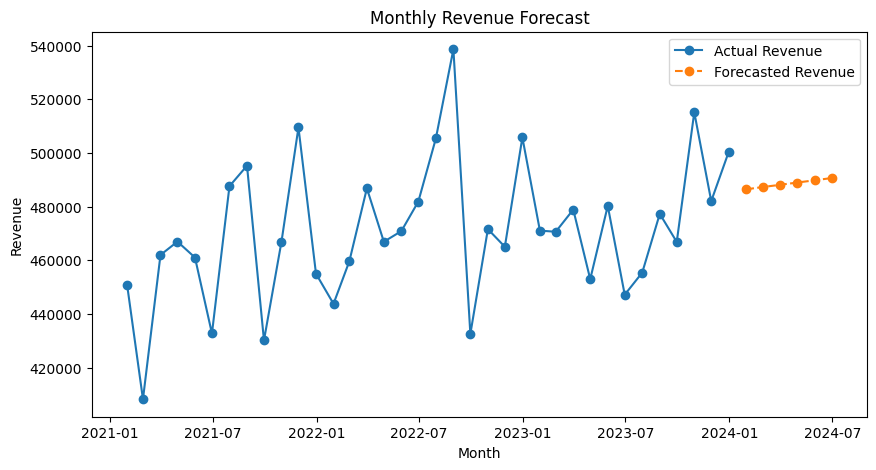

In [69]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue["Order Date"],
    monthly_revenue["Total_revenue_per_order"],
    label="Actual Revenue",
    marker="o"
)

plt.plot(
    forecast_df["Order Date"],
    forecast_df["Forecasted_Revenue"],
    label="Forecasted Revenue",
    marker="o",
    linestyle="--"
)

plt.legend()
plt.title("Monthly Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


In [70]:
category_monthly = (
    df
    .set_index("Order Date")
    .groupby("Category")
    .resample("ME")["Total_revenue_per_order"]
    .sum()
    .reset_index()
)


In [71]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_revenue = (
    df
    .set_index("Order Date")
    .resample("M")["Total_revenue_per_order"]
    .sum()
    .reset_index()
)

monthly_revenue["t"] = np.arange(len(monthly_revenue))


/tmp/ipython-input-1723543728.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Total_revenue_per_order"]


In [72]:
train_df = monthly_revenue.iloc[:-3]
test_df  = monthly_revenue.iloc[-3:]

X_train = train_df[["t"]]
y_train = train_df["Total_revenue_per_order"]

X_test = test_df[["t"]]
y_test = test_df["Total_revenue_per_order"]


In [73]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [74]:
y_pred = model.predict(X_test)


In [75]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2, mae, rmse


(-2.290893500145988, 20340.0054434047, np.float64(24553.10721740865))

In [76]:
comparison_df = test_df.copy()
comparison_df["Predicted_Revenue"] = y_pred
comparison_df["Error"] = comparison_df["Predicted_Revenue"] - comparison_df["Total_revenue_per_order"]
comparison_df


,Order Date,Total_revenue_per_order,t,Predicted_Revenue,Error
33,2023-10-31,515156.50,33,478304.268277,-36852.231723
34,2023-11-30,482071.66,34,478888.254557,-3183.405443
35,2023-12-31,500456.62,35,479472.240837,-20984.379163


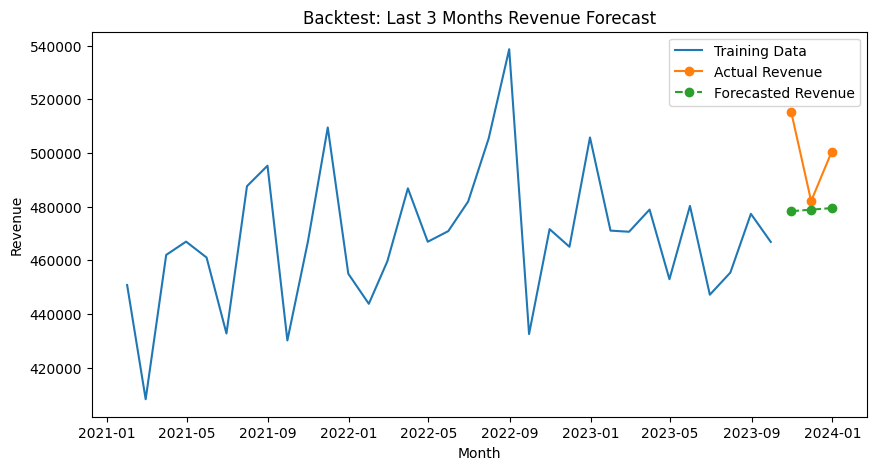

In [77]:
plt.figure(figsize=(10,5))

plt.plot(
    train_df["Order Date"],
    train_df["Total_revenue_per_order"],
    label="Training Data"
)

plt.plot(
    test_df["Order Date"],
    test_df["Total_revenue_per_order"],
    label="Actual Revenue",
    marker="o"
)

plt.plot(
    test_df["Order Date"],
    y_pred,
    label="Forecasted Revenue",
    marker="o",
    linestyle="--"
)

plt.legend()
plt.title("Backtest: Last 3 Months Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


In [78]:
# Seasonal Naive Forecast (12-month seasonality)

seasonal_naive_pred = monthly_revenue.iloc[-15:-12]["Total_revenue_per_order"].values
actual_last_3 = monthly_revenue.iloc[-3:]["Total_revenue_per_order"].values

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_naive = mean_absolute_error(actual_last_3, seasonal_naive_pred)
rmse_naive = np.sqrt(mean_squared_error(actual_last_3, seasonal_naive_pred))

mae_naive, rmse_naive


(21956.130000000005, np.float64(27156.251104770832))

In [79]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

train = monthly_revenue.iloc[:-3]["Total_revenue_per_order"]
test  = monthly_revenue.iloc[-3:]["Total_revenue_per_order"]

hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

hw_fit = hw_model.fit()
hw_pred = hw_fit.forecast(3)


In [80]:
from sklearn.metrics import r2_score

mae_hw = mean_absolute_error(test, hw_pred)
rmse_hw = np.sqrt(mean_squared_error(test, hw_pred))
r2_hw = r2_score(test, hw_pred)

mae_hw, rmse_hw, r2_hw


(37010.22419223917, np.float64(37032.47147210063), -6.486284046709958)

/tmp/ipython-input-2663306724.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(


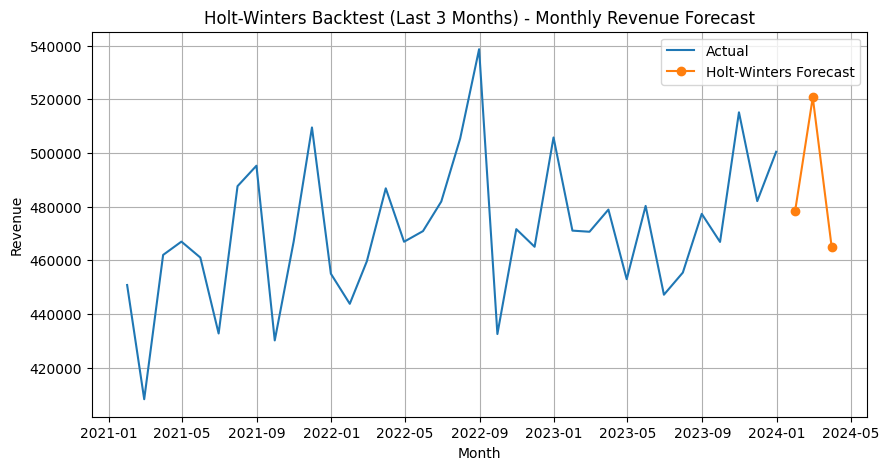

In [81]:
forecast_index = pd.date_range(
    start=monthly_revenue["Order Date"].iloc[-1] + pd.offsets.MonthEnd(1),
    periods=3,
    freq="M"
)

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue["Order Date"], monthly_revenue["Total_revenue_per_order"], label="Actual")
plt.plot(forecast_index, hw_pred, label="Holt-Winters Forecast", marker="o")
plt.legend()
plt.title("Holt-Winters Backtest (Last 3 Months) - Monthly Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

In [82]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(3)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [83]:
mae_sarima = mean_absolute_error(test, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_pred))
r2_sarima = r2_score(test, sarima_pred)

mae_sarima, rmse_sarima, r2_sarima


(23157.675821054436, np.float64(28628.881266215947), -3.4741409542626593)

In [84]:
comparison = pd.DataFrame({
    "Model": ["Seasonal Naive", "Holt-Winters", "SARIMA"],
    "MAE": [mae_naive, mae_hw, mae_sarima],
    "RMSE": [rmse_naive, rmse_hw, rmse_sarima],
    "R2": [None, r2_hw, r2_sarima]
})

comparison


,Model,MAE,RMSE,R2
0,Seasonal Naive,21956.130000,27156.251105,NaN
1,Holt-Winters,37010.224192,37032.471472,-6.486284
2,SARIMA,23157.675821,28628.881266,-3.474141


In [85]:
def rating_bucket(r):
    if r < 3.0:
        return "Low"
    elif r < 4.0:
        return "Medium"
    else:
        return "High"

df["Rating_Category"] = df["Rating"].apply(rating_bucket)


In [86]:
df["Rating_Category"].value_counts(normalize=True) * 100


,proportion
Rating_Category,
Low,48.496
High,26.768
Medium,24.736


In [87]:
df["Rating"].describe()


,Rating
count,25000.000000
mean,3.008728
std,1.159525
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [88]:
df.groupby("Rating_Category")["Delivery Time (Days)"].mean()


,Delivery Time (Days)
Rating_Category,
High,6.298565
Low,6.249753
Medium,6.262128


In [89]:
df.groupby("Rating_Category")["Discount Percentage "].mean()


,Discount Percentage
Rating_Category,
High,0.273156
Low,0.274291
Medium,0.276140


In [90]:
df.groupby("Rating_Category")["Shipping Charges"].mean()


,Shipping Charges
Rating_Category,
High,36.173790
Low,37.011300
Medium,37.059347


In [91]:
pd.crosstab(
    df["Category"],
    df["Rating_Category"],
    normalize="index"
) * 100


Rating_Category,High,Low,Medium
Category,,,
Branded,26.454257,48.625066,24.920677
Imported,26.797775,48.092968,25.109257
Local,26.947267,48.580874,24.471859


In [92]:
pd.crosstab(
    df["Rating_Category"],
    df["Delivery Speed Bucket"],
    normalize="index"
) * 100


Delivery Speed Bucket,Fast,Medium,Slow
Rating_Category,,,
High,11.715481,30.842797,57.441721
Low,12.677334,31.004619,56.318047
Medium,12.597025,31.080207,56.322768


In [93]:
df.groupby("Rating_Category")["Delivery Time (Days)"].median()

df.groupby("Rating_Category")["Delivery Time (Days)"].quantile([0.25, 0.75])


Rating_Category      
High             0.25    4.0
                 0.75    9.0
Low              0.25    3.0
                 0.75    9.0
Medium           0.25    4.0
                 0.75    9.0
Name: Delivery Time (Days), dtype: float64